<a href="https://colab.research.google.com/github/DanielLucero25/house-price-prediction/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
df.shape

(545, 13)

In [7]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [9]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [11]:
df["area"].corr(df["price"])

np.float64(0.5359973457780797)

In [12]:
df.corr(numeric_only=True)["price"].sort_values(ascending=False)

,price
price,1.000000
area,0.535997
bathrooms,0.517545
stories,0.420712
parking,0.384394
bedrooms,0.366494


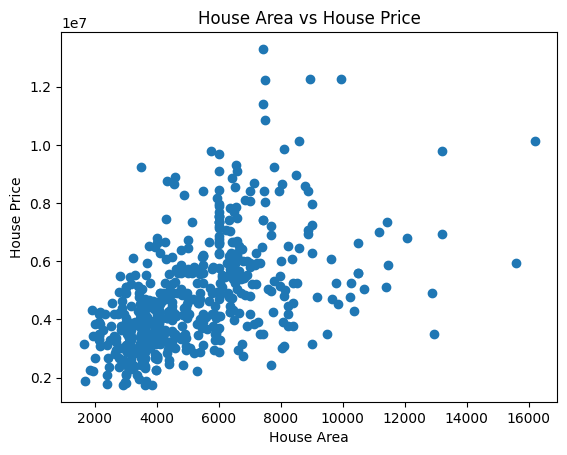

In [13]:
import matplotlib.pyplot as plt

plt.scatter(df["area"], df["price"])
plt.xlabel("House Area")
plt.ylabel("House Price")
plt.title("House Area vs House Price")
plt.show()

In [14]:
df["mainroad"].value_counts()

,count
mainroad,
yes,468
no,77


In [15]:
df["airconditioning"].value_counts()

,count
airconditioning,
no,373
yes,172


In [17]:
df.groupby("airconditioning")["price"].mean()

,price
airconditioning,
no,4.191940e+06
yes,6.013221e+06


In [18]:
df.groupby("basement")["price"].mean()

,price
basement,
no,4.509966e+06
yes,5.242615e+06


In [19]:
df["furnishingstatus"].value_counts()

,count
furnishingstatus,
semi-furnished,227
unfurnished,178
furnished,140


In [20]:
df.groupby("furnishingstatus")["price"].mean()

,price
furnishingstatus,
furnished,5.495696e+06
semi-furnished,4.907524e+06
unfurnished,4.013831e+06


In [ ]:
X = df.drop("price", axis=1)
y = df["price"]

In [22]:
X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [23]:
X = pd.get_dummies(X, drop_first=True)

In [24]:
X.head()

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [25]:
X.columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes',
       'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
       'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
)

In [28]:
X_train.shape

(436, 13)

In [29]:
X_test.shape

(109, 13)

In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
model = LinearRegression()

In [32]:
model.fit(X_train, y_train)

LinearRegression()

In [33]:
y_pred = model.predict(X_test)

In [34]:
y_pred[:5]

array([3093750.79037766, 2569717.10615933, 4286343.0448495 ,
       4942807.88276765, 8239807.84030602])

In [35]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head()

,Actual Price,Predicted Price
0,3220000,3.093751e+06
1,2660000,2.569717e+06
2,3430000,4.286343e+06
3,5600000,4.942808e+06
4,7980000,8.239808e+06


In [36]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print(mae)

829902.2601703422


In [38]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,y_pred)

print(r2)

0.6492219998738651


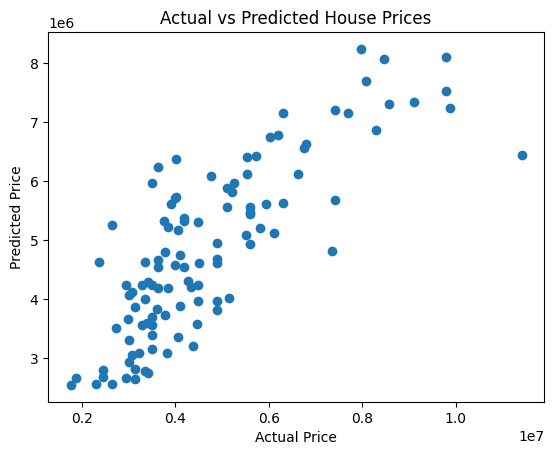

In [39]:
plt.scatter(y_test,y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [40]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,area,2.256113e+02
1,bedrooms,9.135768e+04
2,bathrooms,1.144708e+06
3,stories,3.971775e+05
4,parking,2.815005e+05
5,mainroad_yes,3.777738e+05
6,guestroom_yes,1.946316e+05
7,basement_yes,3.104140e+05
8,hotwaterheating_yes,1.062929e+06
9,airconditioning_yes,8.482672e+05


In [41]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    random_state=42
)

In [45]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [49]:
rf_pred = rf_model.predict(X_test)

In [52]:
rf_mae = mean_absolute_error(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest R2:", rf_r2)

Random Forest MAE: 846842.9388379205
Random Forest R2: 0.6084774330825653


In [54]:
from sklearn.model_selection import cross_val_score

lr_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print(lr_scores)
print("Average R2:", lr_scores.mean())

[0.64859237 0.57520807 0.6759699  0.71012586 0.68709523]
Average R2: 0.6593982845406214


In [55]:
rf_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print(rf_scores)
print("Average R2:", rf_scores.mean())

[0.58070981 0.50330146 0.6542022  0.57207218 0.70165325]
Average R2: 0.6023877805392537


In [59]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "Test MAE": [mae, rf_mae],
    "Test R2": [r2, rf_r2],
    "Cross Validation R2": [lr_scores.mean(), rf_scores.mean()]
})

results

,Model,Test MAE,Test R2,Cross Validation R2
0,Linear Regression,829902.260170,0.649222,0.659398
1,Random Forest,846842.938838,0.608477,0.602388


In conclusionv two regression models were evaluated for predicting house prices: Linear Regression and Random Forest. Linear Regression performed better, achieving an R² of approximately 0.65 and an MAE of approximately 830,000 on the test set. Five-fold cross-validation also showed that Linear Regression performed more consistently, with an average R² of approximately 0.66 compared with 0.60 for Random Forest. Based on these results, Linear Regression was selected as the better model for this dataset.